# Notebook 03 — Leave-One-Family-Out Calibration Validation

## Purpose

This notebook evaluates the proposed one-shot family calibration strategy using leave-one-family-out (LOFO) validation on the literature-derived ASO dataset. Each target family is held out in turn, a global model is trained on the remaining families, and one randomly selected ASO from the held-out family is used to estimate a target-specific additive calibration offset. The simulation is repeated multiple times to characterize calibration robustness.

---

## Workflow

| Cell | Description |
|------|-------------|
| 1 | Repository setup and imports |
| 2 | Load the curated literature feature snapshot |
| 3 | Identify target, family, and response columns; prepare literature dataset |
| 4 | Construct feature matrix, response vector, and family labels |
| 5 | Perform LOFO one-shot calibration simulation |
| 6 | Save results and verify simulation outputs |
| 7 | Generate diagnostic validation plots |
| 8 | Prepare and export Supplementary Table S8 |
| 9 | Generate Supplementary Figure S8 and accompanying caption |

---

## Outputs

This notebook generates:

- LOFO calibration summary statistics
- Repeat-level calibration results
- Supplementary Table S8
- Supplementary Figure S8
- Figure caption helper
- Validation diagnostic plots

All publication outputs are written to the `outputs/figures/`, `outputs/results/`, and `outputs/supplementary_tables/` directories.

Notebook 01 must be executed before running this notebook.

In [1]:
# ============================================================
# Repository setup + imports
# ============================================================

import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# Find repository root from current working directory
cwd = Path.cwd().resolve()

if (cwd / "config.yaml").exists():
    ROOT = cwd
elif (cwd.parent / "config.yaml").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate repository root containing config.yaml. "
        "Run this notebook from the repository root or notebooks/ directory."
    )

os.chdir(ROOT)

# Canonical repository directories
DATA_DIR = ROOT / "data"
FEAT_DIR = ROOT / "features"
SNAPSHOT_DIR = FEAT_DIR / "snapshots"

OUTPUT_DIR = ROOT / "outputs"
MODEL_DIR = OUTPUT_DIR / "model"
FIG_DIR = OUTPUT_DIR / "figures"
RESULTS_DIR = OUTPUT_DIR / "results"
SUPP_TABLE_DIR = OUTPUT_DIR / "supplementary_tables"

SRC_DIR = ROOT / "src"

for d in [
    OUTPUT_DIR,
    MODEL_DIR,
    FIG_DIR,
    RESULTS_DIR,
    SUPP_TABLE_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

# Sanity checks
assert ROOT.exists(), f"ROOT not found: {ROOT}"
assert SRC_DIR.exists(), f"src/ not found: {SRC_DIR}"
assert SNAPSHOT_DIR.exists(), f"features/snapshots/ not found: {SNAPSHOT_DIR}"

# Make src importable
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("ROOT         :", ROOT)
print("SRC_DIR      :", SRC_DIR)
print("SNAPSHOT_DIR :", SNAPSHOT_DIR)
print("RESULTS_DIR  :", RESULTS_DIR)

# Core ML imports
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

ROOT         : /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy
SRC_DIR      : /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/src
SNAPSHOT_DIR : /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/features/snapshots
RESULTS_DIR  : /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/outputs/results


In [2]:
# ============================================================
# Load literature feature snapshot
# ============================================================
SNAPSHOT_FILE = SNAPSHOT_DIR / "P10b_fullbio_snapshot.csv"

if not SNAPSHOT_FILE.exists():
    raise FileNotFoundError(
        f"Missing literature feature snapshot: {SNAPSHOT_FILE}"
    )

df = pd.read_csv(SNAPSHOT_FILE)

print("Loaded:", SNAPSHOT_FILE)
print("Shape :", df.shape)
display(df.head())

Loaded: /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/features/snapshots/P10b_fullbio_snapshot.csv
Shape : (30, 17)


,aso_id,sequence,family,KD,is_wet,neg_dG_bind,neg_duplex_dG,logit_punp,target_gc_pm10,target_gc_pm30,seed_k5_hits,seed_k5_frac,seed_k6_hits,seed_k6_frac,rnaseh_heur,open_state_persist,_split
0,SODr/h146145,GTCGCCCTTCAGCACGCACA,SOD1,0.95,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train
1,SODr/h333611,CCGTCGCCCTTCAGCACGCA,SOD1,0.80,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train
2,SODr146192,CTACAGTTTAGCAGGACAG,SOD1,0.95,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train
3,ASO1,CANGGNATACATTTCTACNAGNCT,SOD1,0.75,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train
4,ASO2,TTNANATGTTTATCANGGNGAT,SOD1,0.60,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train


In [3]:
# ============================================================
# Identify KD, family, and ASO ID columns
# ============================================================
import numpy as np
import pandas as pd

print("Snapshot shape:", df.shape)
print("Snapshot columns:")
print(df.columns.tolist())

# -------- Detect KD column --------
if "KD" in df.columns:
    KD_COL = "KD"
elif "kd" in df.columns:
    KD_COL = "kd"
elif "KD_percent" in df.columns:
    KD_COL = "KD_percent"
elif "%KD" in df.columns:
    KD_COL = "%KD"
else:
    raise ValueError(
        "Could not find KD column (KD / kd / KD_percent / %KD)"
    )

# -------- Detect explicit family/gene column --------
def detect_family_col(cols):
    preferred = [
        "TargetGene", "target_gene", "gene", "Gene",
        "family", "Family", "target", "Target",
        "GeneSymbol", "gene_symbol"
    ]

    for c in preferred:
        if c in cols:
            return c

    for c in cols:
        lc = c.lower()
        if any(k in lc for k in ["gene", "target", "family", "symbol"]):
            return c

    return None


FAM_COL = detect_family_col(df.columns)

# -------- Detect ASO ID column --------
def detect_id_col(cols):
    preferred = [
        "ASO_ID", "aso_id", "asoID",
        "Name", "name", "ID", "id"
    ]

    for c in preferred:
        if c in cols:
            return c

    for c in cols:
        if "aso" in c.lower() and "id" in c.lower():
            return c

    return None


ID_COL = detect_id_col(df.columns)

# -------- Prepare working dataframe --------
lit = df.copy()

# -------- Derive family if none exists --------
if FAM_COL is None:

    if ID_COL is None:
        raise ValueError(
            "No gene/family column found and no ASO ID column "
            "is available to derive family labels."
        )

    print(f"No explicit family column found. Deriving family from {ID_COL}")

    def derive_family(x):
        if pd.isna(x):
            return np.nan

        s = str(x).strip()

        for sep in ["_", "-", " "]:
            if sep in s:
                return s.split(sep)[0]

        return s

    lit["__FAMILY__"] = lit[ID_COL].apply(derive_family)
    FAM_COL = "__FAMILY__"

# -------- Optional literature filter --------
if "source" in lit.columns:
    lit = lit[
        lit["source"].astype(str).str.lower() == "literature"
    ].copy()

# -------- Drop missing --------
lit = lit[
    lit[KD_COL].notna() &
    lit[FAM_COL].notna()
].copy()

# -------- Type coercion --------
lit[KD_COL] = pd.to_numeric(lit[KD_COL], errors="raise")
lit[FAM_COL] = lit[FAM_COL].astype(str)

# -------- Final sanity prints --------
print("\nUsing KD_COL :", KD_COL)
print("Using FAM_COL:", FAM_COL)

if ID_COL is not None:
    print("Using ID_COL :", ID_COL)

print("Working dataset shape:", lit.shape)

print("\nFamily counts:")
print(lit[FAM_COL].value_counts())

display(lit.head())

Snapshot shape: (30, 17)
Snapshot columns:
['aso_id', 'sequence', 'family', 'KD', 'is_wet', 'neg_dG_bind', 'neg_duplex_dG', 'logit_punp', 'target_gc_pm10', 'target_gc_pm30', 'seed_k5_hits', 'seed_k5_frac', 'seed_k6_hits', 'seed_k6_frac', 'rnaseh_heur', 'open_state_persist', '_split']

Using KD_COL : KD
Using FAM_COL: family
Using ID_COL : aso_id
Working dataset shape: (30, 17)

Family counts:
family
SOD1       6
DAZ        6
C9ORF72    5
STMN2      5
AR         3
ATXN2      2
FAM        2
FUS        1
Name: count, dtype: int64


,aso_id,sequence,family,KD,is_wet,neg_dG_bind,neg_duplex_dG,logit_punp,target_gc_pm10,target_gc_pm30,seed_k5_hits,seed_k5_frac,seed_k6_hits,seed_k6_frac,rnaseh_heur,open_state_persist,_split
0,SODr/h146145,GTCGCCCTTCAGCACGCACA,SOD1,0.95,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train
1,SODr/h333611,CCGTCGCCCTTCAGCACGCA,SOD1,0.80,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train
2,SODr146192,CTACAGTTTAGCAGGACAG,SOD1,0.95,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train
3,ASO1,CANGGNATACATTTCTACNAGNCT,SOD1,0.75,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train
4,ASO2,TTNANATGTTTATCANGGNGAT,SOD1,0.60,False,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,train


In [4]:
# ============================================================
# Build feature matrix X / y
# ============================================================
NON_FEATURE_COLS = {
    KD_COL,
    FAM_COL,
    "ASO_ID", "aso_id",
    "Sequence", "sequence",
    "TargetGene", "target_gene",
    "source", "split", "fold"
}

feature_cols = [
    c for c in lit.columns
    if c not in NON_FEATURE_COLS
    and pd.api.types.is_numeric_dtype(lit[c])
]

if len(feature_cols) == 0:
    raise RuntimeError(
        "No numeric feature columns found in literature snapshot."
    )

print("Feature columns:")
for c in feature_cols:
    print(" -", c)

X = lit[feature_cols].to_numpy(dtype=float)
y = lit[KD_COL].to_numpy(dtype=float)
fam = lit[FAM_COL].to_numpy()

if not np.isfinite(X).all():
    raise RuntimeError("Feature matrix contains NaN or infinite values.")

if not np.isfinite(y).all():
    raise RuntimeError("Outcome vector contains NaN or infinite values.")

print("\nX shape:", X.shape)
print("# features:", len(feature_cols))
print("# samples :", len(y))
print("# families:", len(np.unique(fam)))


Feature columns:
 - is_wet
 - neg_dG_bind
 - neg_duplex_dG
 - logit_punp
 - target_gc_pm10
 - target_gc_pm30
 - seed_k5_hits
 - seed_k5_frac
 - seed_k6_hits
 - seed_k6_frac
 - rnaseh_heur
 - open_state_persist

X shape: (30, 12)
# features: 12
# samples : 30
# families: 8


In [5]:
# ============================================================
# LOFO + one-shot calibration simulation
# ============================================================
def lofo_one_shot_calibration(
    X,
    y,
    fam,
    repeats=100,
    alpha=1.0,
    seed=0
):
    rng = np.random.default_rng(seed)
    families = np.unique(fam)

    summary_rows = []
    repeat_rows = []

    for f in families:
        idx_test = np.where(fam == f)[0]
        idx_train = np.where(fam != f)[0]

        # Need at least 1 calibrator + 1 independent evaluation point
        if len(idx_test) < 2:
            continue

        X_tr, y_tr = X[idx_train], y[idx_train]
        X_te, y_te = X[idx_test], y[idx_test]

        # Train only on all other families
        model = Ridge(alpha=alpha)
        model.fit(X_tr, y_tr)

        # Predict the held-out family
        yhat_te = model.predict(X_te)

        # Overall uncalibrated MAE for the held-out family
        base_mae_all = mean_absolute_error(y_te, yhat_te)

        improvements = []

        for r in range(repeats):

            # Randomly select one ASO from the held-out family
            # to serve as the one-shot calibration reference
            j = rng.integers(0, len(idx_test))

            # One-shot additive family offset
            delta = y_te[j] - yhat_te[j]

            # Evaluate only on the remaining ASOs
            mask = np.ones(len(idx_test), dtype=bool)
            mask[j] = False

            base_mae = mean_absolute_error(
                y_te[mask],
                yhat_te[mask]
            )

            calib_mae = mean_absolute_error(
                y_te[mask],
                yhat_te[mask] + delta
            )

            improvement = base_mae - calib_mae
            improvements.append(improvement)

            repeat_row = {
                "family": f,
                "repeat": r,
                "calibrator_index": int(idx_test[j]),
                "base_mae": base_mae,
                "calib_mae": calib_mae,
                "improvement": improvement,
            }

            # Save the actual calibrator ASO ID when available
            if ID_COL is not None:
                repeat_row["calibrator_aso_id"] = str(
                    lit.iloc[idx_test[j]][ID_COL]
                )

            repeat_rows.append(repeat_row)

        improvements = np.asarray(improvements, dtype=float)

        summary_rows.append({
            "family": f,
            "n_family": len(idx_test),
            "base_mae_uncalibrated": base_mae_all,
            "improvement_mean": improvements.mean(),
            "improvement_median": np.median(improvements),
            "improvement_std": improvements.std(ddof=1),
            "ci95_low": np.percentile(improvements, 2.5),
            "ci95_high": np.percentile(improvements, 97.5),
            "fraction_improved": np.mean(improvements > 0),
        })

    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values("improvement_mean", ascending=False)
        .reset_index(drop=True)
    )
    repeats_df = pd.DataFrame(repeat_rows)
    return summary_df, repeats_df
# ------------------------------------------------------------
# Run LOFO calibration validation
# ------------------------------------------------------------
LOFO_REPEATS = 1000
LOFO_ALPHA = 1.0
LOFO_SEED = 0

summary_df, repeats_df = lofo_one_shot_calibration(
    X,
    y,
    fam,
    repeats=LOFO_REPEATS,
    alpha=LOFO_ALPHA,
    seed=LOFO_SEED,
)

print("Families evaluated:", len(summary_df))
print("Repeats per family:", LOFO_REPEATS)
print("Ridge alpha:", LOFO_ALPHA)
print("Random seed:", LOFO_SEED)
display(summary_df)

Families evaluated: 7
Repeats per family: 1000
Ridge alpha: 1.0
Random seed: 0


,family,n_family,base_mae_uncalibrated,improvement_mean,improvement_median,improvement_std,ci95_low,ci95_high,fraction_improved
0,DAZ,6,0.246360,0.196917,0.203759,0.018569,0.162783,0.213177,1.000
1,ATXN2,2,0.094811,0.074931,0.084811,0.010004,0.064811,0.084811,1.000
2,C9ORF72,5,0.108058,-0.002591,0.045048,0.056699,-0.079904,0.045048,0.581
3,FAM,2,0.105798,-0.004705,0.049534,0.056256,-0.062995,0.049534,0.518
4,STMN2,5,0.229822,-0.010536,0.008185,0.066415,-0.091815,0.058185,0.595
5,AR,3,0.216880,-0.017523,0.000000,0.023631,-0.049360,0.000000,0.000
6,SOD1,6,0.162532,-0.028003,-0.022443,0.039397,-0.077481,0.022519,0.332


In [6]:
# ============================================================
# Save and verify LOFO calibration outputs
# ============================================================

OUT_DIR = RESULTS_DIR / "lofo_one_shot_calibration"
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUT_DIR / "summary.csv"
repeats_path = OUT_DIR / "repeats_long.csv"

summary_df.to_csv(summary_path, index=False)
repeats_df.to_csv(repeats_path, index=False)


# ------------------------------------------------------------
# Verify repeat counts
# ------------------------------------------------------------
repeat_counts = (
    repeats_df
    .groupby("family")["repeat"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nRepeats produced per family:")
print(repeat_counts)

print("\nTotal repeat rows:", len(repeats_df))
print("Families evaluated:", repeats_df["family"].nunique())

expected_rows = len(summary_df) * LOFO_REPEATS

if len(repeats_df) != expected_rows:
    print(
        f"[warn] Expected {expected_rows} repeat rows, "
        f"but found {len(repeats_df)}."
    )
else:
    print("Repeat-count verification passed.")



Repeats produced per family:
family
AR         1000
ATXN2      1000
C9ORF72    1000
DAZ        1000
FAM        1000
SOD1       1000
STMN2      1000
Name: repeat, dtype: int64

Total repeat rows: 7000
Families evaluated: 7
Repeat-count verification passed.


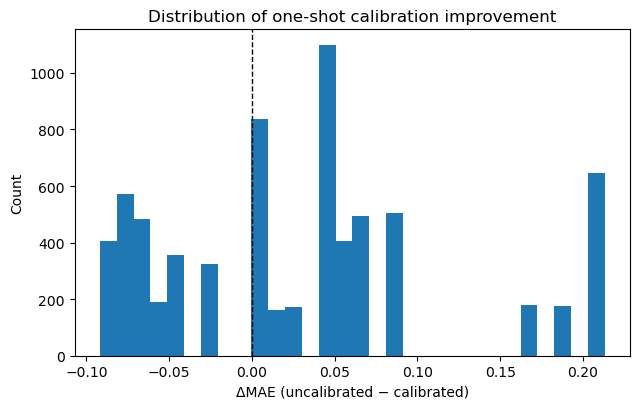

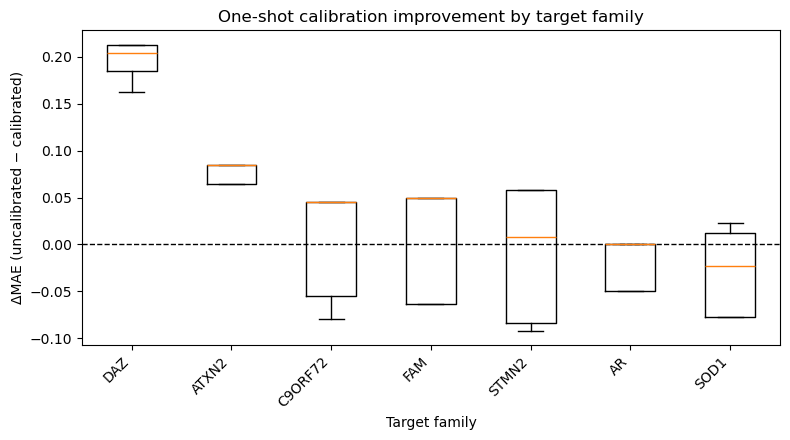

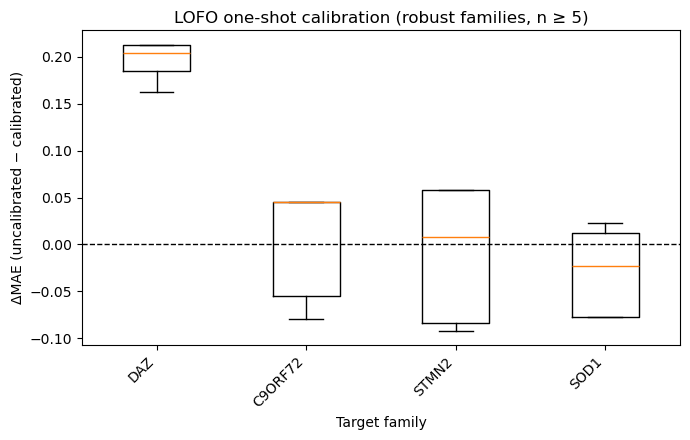

In [7]:
# ============================================================
# LOFO diagnostic plots
# ============================================================
import matplotlib.pyplot as plt

if repeats_df.empty: print("No repeat-level results available to plot.")
else:
    # --------------------------------------------------------
    # A. Overall distribution of calibration improvement
    # --------------------------------------------------------
    plt.figure(figsize=(6.5, 4.2))
    plt.hist(repeats_df["improvement"].to_numpy(), bins=30)
    plt.axvline(
        0,
        linestyle="--",
        linewidth=1,
        color="black"
    )
    plt.title("Distribution of one-shot calibration improvement")
    plt.xlabel("ΔMAE (uncalibrated − calibrated)")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # B. Improvement distributions across all evaluated families
    # --------------------------------------------------------
    all_fams = (
        summary_df
        .sort_values(
            "improvement_mean",
            ascending=False
        )["family"]
        .tolist()
    )

    data_all = [
        repeats_df.loc[
            repeats_df["family"] == f,
            "improvement"
        ].to_numpy()
        for f in all_fams
    ]

    plt.figure(figsize=(8, 4.5))
    plt.boxplot(data_all, tick_labels=all_fams, showfliers=False)
    plt.axhline(
        0,
        linestyle="--",
        linewidth=1,
        color="black"
    )
    plt.title("One-shot calibration improvement by target family")
    plt.xlabel("Target family")
    plt.ylabel("ΔMAE (uncalibrated − calibrated)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # C. Robust families only (n ≥ 5)
    # --------------------------------------------------------
    robust_fams = (
        summary_df
        .query("n_family >= 5")
        .sort_values(
            "improvement_mean",
            ascending=False
        )["family"]
        .tolist()
    )

    data_robust = [
        repeats_df.loc[
            repeats_df["family"] == f,
            "improvement"
        ].to_numpy()
        for f in robust_fams
    ]

    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data_robust, tick_labels=robust_fams, showfliers=False)
    plt.axhline(
        0,
        linestyle="--",
        linewidth=1,
        color="black"
    )
    plt.title("LOFO one-shot calibration " "(robust families, n ≥ 5)")
    plt.xlabel("Target family")
    plt.ylabel("ΔMAE (uncalibrated − calibrated)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [8]:
# ============================================================
# Prepare and save Supplementary Table S8
# ============================================================
# ------------------------------------------------------------
# Validate LOFO outputs
# ------------------------------------------------------------
required_summary_cols = {
    "family",
    "n_family",
    "base_mae_uncalibrated",
    "improvement_mean",
    "improvement_median",
    "improvement_std",
    "ci95_low",
    "ci95_high",
    "fraction_improved",
}

required_repeats_cols = {
    "family",
    "repeat",
    "improvement",
}

missing_summary = required_summary_cols - set(summary_df.columns)
missing_repeats = required_repeats_cols - set(repeats_df.columns)
if missing_summary: raise RuntimeError(f"summary_df missing required columns: {missing_summary}")
if missing_repeats: raise RuntimeError(f"repeats_df missing required columns: {missing_repeats}")

print("LOFO output validation passed.")
print("Families in summary:", summary_df["family"].nunique())
print("Families in repeats:", repeats_df["family"].nunique())

# ------------------------------------------------------------
# Robust vs all-family summaries
# ------------------------------------------------------------
main_df = (
    summary_df[
        summary_df["n_family"] >= 5
    ]
    .copy()
    .sort_values(
        "improvement_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

supp_df = summary_df.copy()
print("\nRobust families (n ≥ 5):")
display(main_df)

# ------------------------------------------------------------
# Prepare Supplementary Table S8
# Robust families first, followed by smaller families
# ------------------------------------------------------------
table_df = summary_df.copy()

table_df["__robust__"] = (
    table_df["n_family"] >= 5
).astype(int)

table_df = (
    table_df
    .sort_values(
        by=[
            "__robust__",
            "improvement_mean",
            "n_family",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .drop(columns=["__robust__"])
    .reset_index(drop=True)
)

table_df_renamed = table_df.rename(
    columns={
        "family": "Family",
        "n_family": "n (family)",
        "base_mae_uncalibrated": "MAE (uncalibrated)",
        "improvement_mean": "ΔMAE mean",
        "improvement_median": "ΔMAE median",
        "improvement_std": "ΔMAE SD",
        "ci95_low": "ΔMAE 95% CI low",
        "ci95_high": "ΔMAE 95% CI high",
        "fraction_improved": "Fraction improved",
    }
)

# ------------------------------------------------------------
# Save Supplementary Table S8
# ------------------------------------------------------------
table_path = (SUPP_TABLE_DIR / "Supplementary_Table_S8_LOFO_one_shot_summary.csv")
table_df_renamed.to_csv(table_path, index=False)

print("\nSaved Supplementary Table S8:")
display(table_df_renamed)

LOFO output validation passed.
Families in summary: 7
Families in repeats: 7

Robust families (n ≥ 5):


,family,n_family,base_mae_uncalibrated,improvement_mean,improvement_median,improvement_std,ci95_low,ci95_high,fraction_improved
0,DAZ,6,0.246360,0.196917,0.203759,0.018569,0.162783,0.213177,1.000
1,C9ORF72,5,0.108058,-0.002591,0.045048,0.056699,-0.079904,0.045048,0.581
2,STMN2,5,0.229822,-0.010536,0.008185,0.066415,-0.091815,0.058185,0.595
3,SOD1,6,0.162532,-0.028003,-0.022443,0.039397,-0.077481,0.022519,0.332



Saved Supplementary Table S8:


,Family,n (family),MAE (uncalibrated),ΔMAE mean,ΔMAE median,ΔMAE SD,ΔMAE 95% CI low,ΔMAE 95% CI high,Fraction improved
0,DAZ,6,0.246360,0.196917,0.203759,0.018569,0.162783,0.213177,1.000
1,C9ORF72,5,0.108058,-0.002591,0.045048,0.056699,-0.079904,0.045048,0.581
2,STMN2,5,0.229822,-0.010536,0.008185,0.066415,-0.091815,0.058185,0.595
3,SOD1,6,0.162532,-0.028003,-0.022443,0.039397,-0.077481,0.022519,0.332
4,ATXN2,2,0.094811,0.074931,0.084811,0.010004,0.064811,0.084811,1.000
5,FAM,2,0.105798,-0.004705,0.049534,0.056256,-0.062995,0.049534,0.518
6,AR,3,0.216880,-0.017523,0.000000,0.023631,-0.049360,0.000000,0.000


CREATE IMAGES FOR SUPPLEMENTARY S8

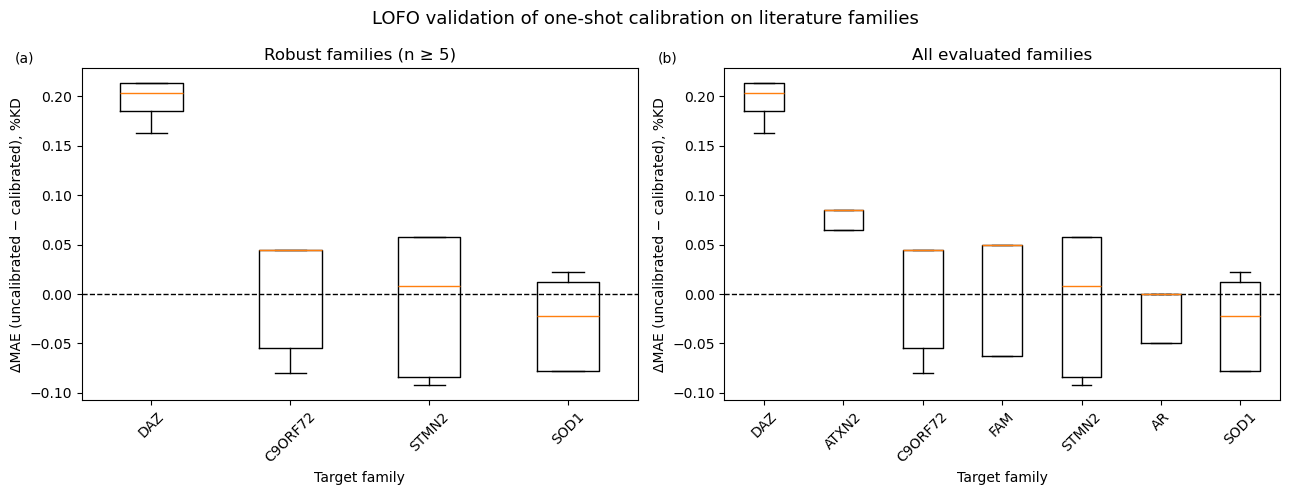

807

In [9]:
# ============================================================
# Supplementary Figure S8 -- LOFO validation of one-shot calibration
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def get_ordered_families(df_summary, nmin=None):
    d = df_summary.copy()

    if nmin is not None:
        d = d[d["n_family"] >= nmin]

    return (
        d
        .sort_values(
            "improvement_mean",
            ascending=False
        )["family"]
        .tolist()
    )

def data_for_families(repeats, fam_list):
    return [
        repeats.loc[
            repeats["family"] == f,
            "improvement"
        ].to_numpy()
        for f in fam_list
    ]

# ------------------------------------------------------------
# Family ordering
# ------------------------------------------------------------
robust_fams = get_ordered_families(summary_df,nmin=5)
all_fams = get_ordered_families(summary_df)
data_robust = data_for_families(repeats_df, robust_fams)
data_all = data_for_families(repeats_df, all_fams)

# ------------------------------------------------------------
# Build two-panel supplementary figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# Panel A — robust families
ax = axes[0]
ax.boxplot(
    data_robust,
    tick_labels=robust_fams,
    showfliers=False
)
ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    color="black"
)
ax.set_title("Robust families (n ≥ 5)")
ax.set_xlabel("Target family")
ax.set_ylabel("ΔMAE (uncalibrated − calibrated), %KD")
ax.tick_params(axis="x",rotation=45)
ax.text(
    -0.12,
    1.05,
    "(a)",
    transform=ax.transAxes,
    fontsize=10,
    va="top"
)

# Panel B — all evaluated families
ax = axes[1]
ax.boxplot(
    data_all,
    tick_labels=all_fams,
    showfliers=False
)
ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    color="black"
)

ax.set_title("All evaluated families")
ax.set_xlabel("Target family")
ax.set_ylabel("ΔMAE (uncalibrated − calibrated), %KD")
ax.tick_params(axis="x", rotation=45)
ax.text(
    -0.12,
    1.05,
    "(b)",
    transform=ax.transAxes,
    fontsize=10,
    va="top"
)

fig.suptitle("LOFO validation of one-shot calibration on literature families", fontsize=13)
plt.tight_layout()

fig_png = (FIG_DIR / "Supplementary_Figure_S8_LOFO_one_shot_boxplots.png")
fig_pdf = (FIG_DIR / "Supplementary_Figure_S8_LOFO_one_shot_boxplots.pdf")

plt.savefig(fig_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_pdf, bbox_inches="tight")
plt.show()

caption = f"""Supplementary Figure S8. Leave-one-family-out validation of one-shot calibration on literature-derived ASO families.

Distributions show the change in mean absolute error (ΔMAE = uncalibrated − calibrated) resulting from one-shot family calibration under a leave-one-family-out (LOFO) simulation. For each family, a single ASO was randomly selected as a calibration reference, an additive offset was applied to the remaining ASOs, and performance was evaluated on the held-out family. This procedure was repeated {LOFO_REPEATS:,} times per family.

(A) Robust families with at least five ASOs (n ≥ 5).
(B) All evaluated families, including smaller family groups, shown for completeness.

Positive ΔMAE values indicate improved accuracy following calibration. The dashed horizontal line denotes no net change in error.
"""

caption_path = (RESULTS_DIR / "Supplementary_Figure_S8_caption.txt")
caption_path.write_text(caption, encoding="utf-8")
